In [34]:
import kagglehub

path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\PC\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2


In [35]:
import os

path = r"C:\Users\PC\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2"

print(os.listdir(path))

['seg_pred', 'seg_test', 'seg_train']


In [36]:
train_path = path + "/seg_train/seg_train"
print(os.listdir(train_path))

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [37]:
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((150,150)),
    transforms.ToTensor()
])

train_dataset = ImageFolder(train_path, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print("Nombre d'images :", len(train_dataset))

Nombre d'images : 14034


In [38]:
!pip install torchvision

In [39]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 150, 150])
torch.Size([32])


In [40]:
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*36*36, 128),
            nn.ReLU(),
            nn.Linear(128, 6)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

In [41]:
images.shape

torch.Size([32, 3, 150, 150])

In [42]:
import torch

model = CNN()

images, labels = next(iter(train_loader))
outputs = model(images)

print(outputs.shape)

torch.Size([32, 6])


In [43]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [44]:
#Optimiser + LOSS
import torch.optim as optim
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [45]:
# Training loop
epochs = 1

for epoch in range(epochs):
    running_loss = 0.0

    for images, labels in train_loader:
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}")

Epoch 1, Loss: 0.981486898484154


In [46]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in train_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 76.54%


In [47]:
import torch
torch.save(model.state_dict(), "daouda_model.pth")

In [63]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Générateur
datagen = ImageDataGenerator(rescale=1./255)

train_generator = datagen.flow_from_directory(
    train_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical'
)

# Modèle CNN léger
model_tf = models.Sequential([
    layers.Conv2D(16, (3,3), activation='relu', input_shape=(150,150,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(6, activation='softmax')
])

model_tf.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Entraînement
model_tf.fit(train_generator, epochs=3)

# ✅ SAUVEGARDE MODERNE (.keras)
model_tf.save("daouda_model.keras")

Found 14034 images belonging to 6 classes.
Epoch 1/3
439/439 ━━━━━━━━━━━━━━━━━━━━ 95s 206ms/step - accuracy: 0.6160 - loss: 0.9990
Epoch 2/3
439/439 ━━━━━━━━━━━━━━━━━━━━ 84s 192ms/step - accuracy: 0.7677 - loss: 0.6473
Epoch 3/3
439/439 ━━━━━━━━━━━━━━━━━━━━ 85s 193ms/step - accuracy: 0.8376 - loss: 0.4640


In [49]:
history = model_tf.fit(train_generator, epochs=3)

print(history.history.keys())

Epoch 1/3
439/439 ━━━━━━━━━━━━━━━━━━━━ 87s 198ms/step - accuracy: 0.9071 - loss: 0.2680
Epoch 2/3
439/439 ━━━━━━━━━━━━━━━━━━━━ 73s 166ms/step - accuracy: 0.9510 - loss: 0.1589
Epoch 3/3
439/439 ━━━━━━━━━━━━━━━━━━━━ 74s 168ms/step - accuracy: 0.9747 - loss: 0.0904
dict_keys(['accuracy', 'loss'])


In [50]:
print("Accuracy:", history.history['accuracy'])
print("Loss:", history.history['loss'])

Accuracy: [0.9070827960968018, 0.9510474801063538, 0.9747042655944824]
Loss: [0.2679970860481262, 0.1588565856218338, 0.09041965007781982]


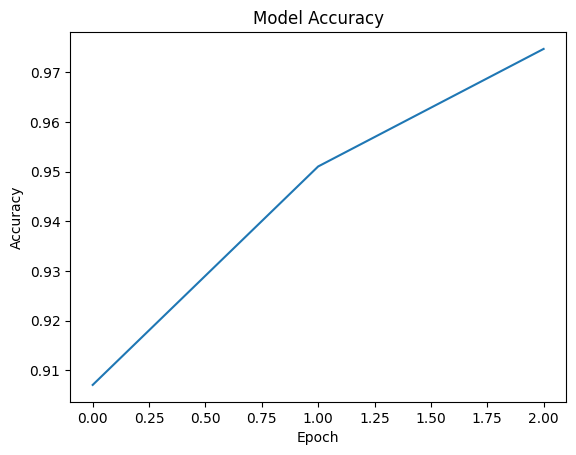

In [51]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

Le modèle montre une évolution positive de l’accuracy au cours des époques, ce qui indique un bon apprentissage.
La diminution de la loss confirme que le réseau améliore progressivement ses prédictions.

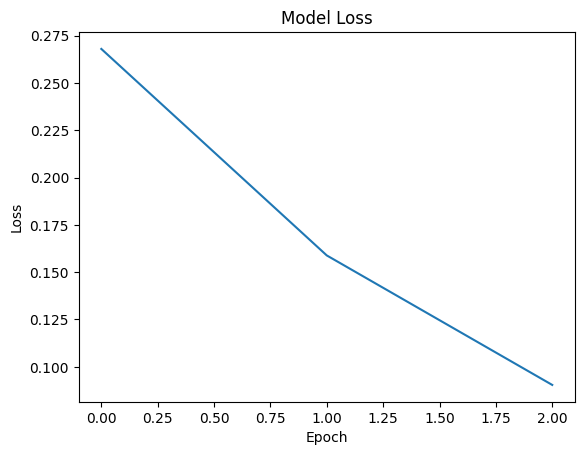

In [52]:
plt.plot(history.history['loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [53]:
!pip install flask

In [54]:
import os

print(os.getcwd())
print(os.listdir())

c:\Users\PC\Documents\Nouveau dossier (5)
['app.py', 'Assignme_c_vision.ipynb', 'daouda_model.h5', 'daouda_model.keras', 'daouda_model.pth', 'templates']


In [55]:
model_tf.fit(train_generator, epochs=3)

model_tf.save("daouda_model.keras")

Epoch 1/3
439/439 ━━━━━━━━━━━━━━━━━━━━ 103s 234ms/step - accuracy: 0.9841 - loss: 0.0609
Epoch 2/3
439/439 ━━━━━━━━━━━━━━━━━━━━ 90s 206ms/step - accuracy: 0.9805 - loss: 0.0668
Epoch 3/3
439/439 ━━━━━━━━━━━━━━━━━━━━ 84s 192ms/step - accuracy: 0.9866 - loss: 0.0496


In [56]:
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = datagen.flow_from_directory(
    train_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    train_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.


In [57]:
history = model_tf.fit(
    train_generator,
    validation_data=val_generator,
    epochs=3
)

Epoch 1/3
351/351 ━━━━━━━━━━━━━━━━━━━━ 78s 220ms/step - accuracy: 0.9873 - loss: 0.0472 - val_accuracy: 0.9711 - val_loss: 0.1081
Epoch 2/3
351/351 ━━━━━━━━━━━━━━━━━━━━ 73s 207ms/step - accuracy: 0.9923 - loss: 0.0374 - val_accuracy: 0.9922 - val_loss: 0.0324
Epoch 3/3
351/351 ━━━━━━━━━━━━━━━━━━━━ 77s 218ms/step - accuracy: 0.9968 - loss: 0.0207 - val_accuracy: 0.9950 - val_loss: 0.0246


In [59]:
model_tf.save("daouda_model.h5")

In [62]:
model = tf.keras.models.load_model("daouda_model.h5")